In [6]:
import os
mlflow_tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "")
mlflow_model_name = os.getenv("MODEL_NAME", "")
mlflow_experiment_name = os.getenv("MLFLOW_EXPERIMENT_NAME", "")


In [7]:
from typing import Literal
import mlflow

def initialize_mlflow_tracking(tracking_uri, stage: Literal["dev", "prod"], exp_name="california_housing_experiment"):

    mlflow.set_tracking_uri(tracking_uri)
    exp_name_tag = exp_name+"_"+stage

    # Check if it exists to avoid redundancy or errors
    exp = mlflow.get_experiment_by_name(exp_name_tag)

    if not exp:
        # Set the custom artifact path only once at creation
        mlflow.create_experiment(exp_name_tag, artifact_location=None, tags={"stage": stage})

    # Set the active experiment
    mlflow.set_experiment(exp_name_tag)

    return exp_name_tag


exp_name_tag = initialize_mlflow_tracking(mlflow_tracking_uri, stage="dev")
exp_name_tag

'california_housing_experiment_dev'

## `Problem Definition`

- A prediction of a district’s median housing price
- The current situation: the district housing prices are currently estimated manually by experts, they often realize that their estimates were off by more than 30%.
- Select a Performance Measure: root mean squared error (RMSE)

## `Data Ingestion`

To build our model we will train it on the California census data.

In [8]:
from pathlib import Path
import urllib.request
import tarfile
import pandas as pd
import os

def download_housing_data():
    
    BASE_DIR = Path(os.getcwd()).parent
    # print(f"Base directory: {BASE_DIR}")

    DATASETS_DIR = BASE_DIR / "assets" / "data"
    TEMP_DIR = BASE_DIR / "assets" / "temp"
    TARBALL_PATH = TEMP_DIR / "housing.tgz"
    CSV_PATH = DATASETS_DIR / "housing" / "housing.csv"


    DATASETS_DIR.mkdir(parents=True, exist_ok=True)
    TEMP_DIR.mkdir(parents=True, exist_ok=True)

    if not CSV_PATH.is_file():
        url = "https://github.com/ageron/data/raw/main/housing.tgz"

        # Download tarball
        urllib.request.urlretrieve(url, TARBALL_PATH)

        # Extract
        with tarfile.open(TARBALL_PATH) as housing_tarball:
            housing_tarball.extractall(path=DATASETS_DIR, filter="data")

        # Remove tar file after extraction
        TARBALL_PATH.unlink()

    return CSV_PATH



In [9]:
housing_csv = download_housing_data()
housing_full = pd.read_csv(housing_csv)

## `Data Quality Check`

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
housing_full.shape

(20640, 10)

In [12]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [14]:
housing_full.duplicated().sum()

np.int64(0)

In [15]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [16]:
from sklearn.feature_selection import VarianceThreshold

# You can set a small non-zero threshold to remove quasi-constant features based on variance.
selector = VarianceThreshold(threshold=0.01)

X_num_filtered = selector.fit_transform(housing_full.select_dtypes(include=[np.number]))

# Check features that were removed
removed_features = housing_full.select_dtypes(include=[np.number]).columns[~selector.get_support()]
if len(removed_features) > 0:
    print("Features to be removed (constant features):")
    print(removed_features.tolist())
else:
    print("No constant numerical features to remove by VarianceThreshold.")


No constant numerical features to remove by VarianceThreshold.


## `Create a test set`

- As this data won't be updated in the future So, we are going to use Seeded random split approach.
- Also this data contains only 20,640 entries so stratified split eliminate the risk of introducing a significant sampling bias.

Assumption:
Suppose the median income is a very important attribute to predict median housing prices. You may want to ensure that the test set is representative of the various categories of incomes in the whole dataset. Since the median income is a continuous numerical attribute, you first need to create an income category attribute.

<Axes: >

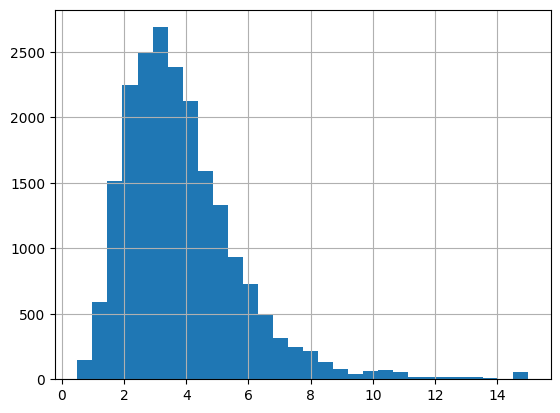

In [17]:
housing_full['median_income'].hist(bins=30)

In [18]:
import numpy as np
import pandas as pd

bins = [0., 1.5, 3.0, 4.5, 6., np.inf]
labels = [1, 2, 3, 4, 5]

housing_full['income_cat'] = pd.cut(
    housing_full['median_income'],
    bins=bins,
    labels=labels,
    include_lowest=True
)



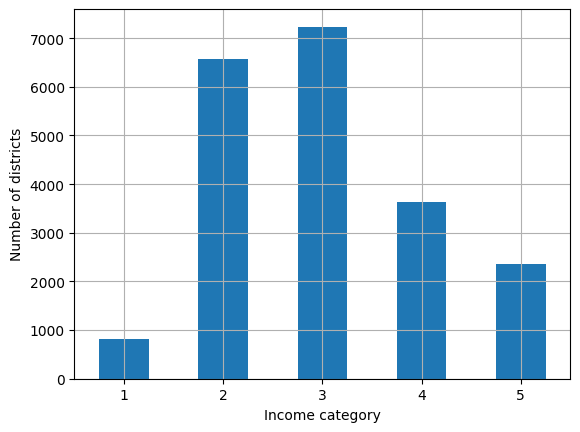

In [19]:
housing_full['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import mlflow


def income_cat_stratified_split(csv_path:str,
                                test_size:float=0.2,
                                random_state:int=42,
                                bins:list=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                labels:list=[1, 2, 3, 4, 5],
                                include_lowest:bool=True):
    
    data = pd.read_csv(csv_path)
    data["income_cat"] = pd.cut(data["median_income"],
                                bins=bins,
                                labels=labels,
                                include_lowest=include_lowest)
    
    strat_train_set, strat_test_set = train_test_split(data, test_size=test_size, random_state=random_state, stratify=data["income_cat"])

    mlflow.log_param("test_size", test_size)
    mlflow.log_param("random_state", random_state)
    mlflow.log_param("stratify", "income_cat")

    ## No need for income_cat anymore
    strat_train_set.drop("income_cat", axis=1, inplace=True)
    strat_test_set.drop("income_cat", axis=1, inplace=True)

    # train_dataset = mlflow.data.from_pandas(
    # strat_train_set, source=csv_path.resolve().as_uri(), name="california-housing-train", targets="median_house_value")

    # test_dataset = mlflow.data.from_pandas(
    # strat_test_set, source=csv_path.resolve().as_uri(), name="california-housing-test", targets="median_house_value")

    # mlflow.log_input(train_dataset, context="training")
    # mlflow.log_input(test_dataset, context="testing")

    
    return strat_train_set, strat_test_set

In [21]:
strat_train_set, strat_test_set = income_cat_stratified_split(str(housing_csv), test_size=0.2, random_state=42)

In [22]:
housing_tr = strat_train_set.copy()

## `Handling missing data`

In [23]:
null_rows_idx = housing_tr.isnull().any(axis=1)
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,85900.0,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,150400.0,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,161200.0,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,500001.0,<1H OCEAN


We can clearly see that NaN values are compeletly random, So we are good to go with impute missing values. and as data features are almost skewed then for numerical data impute with the median value and for categorical data impute with most-freq value.

## `Exploratory Data Analysis (EDA)`

In [24]:
housing_num_tr = housing_tr.select_dtypes(include=[np.number])
housing_cat_tr = housing_tr.select_dtypes(exclude=[np.number])

### Univariate Analysis (Feature-level behavior)

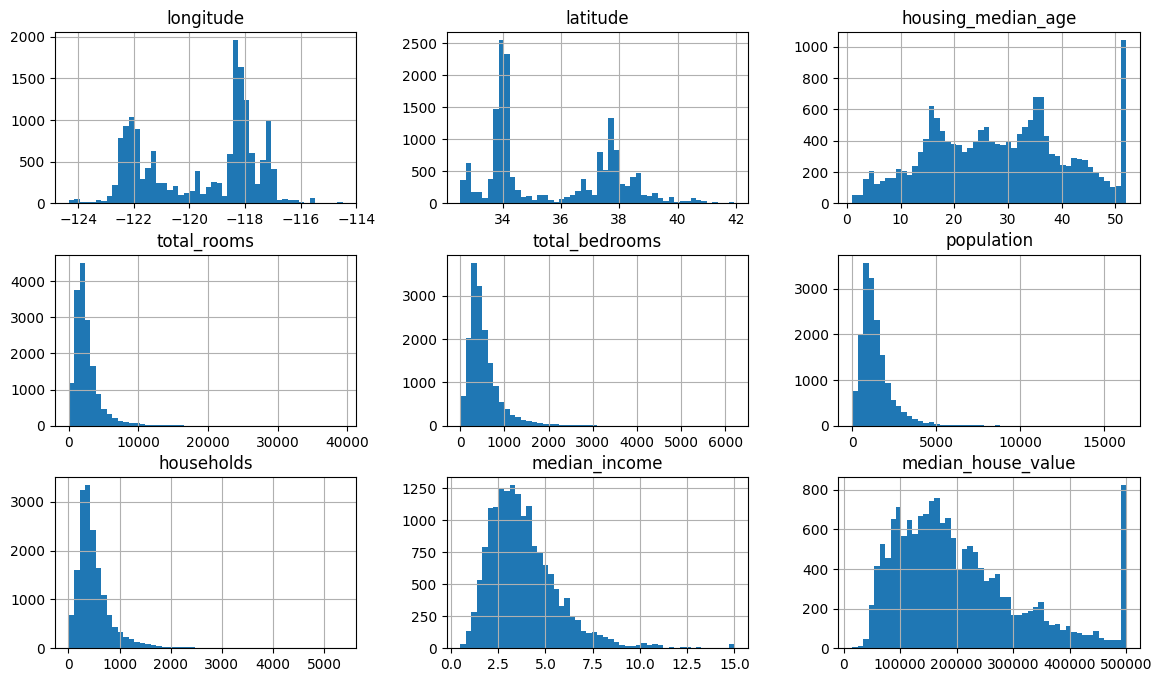

In [25]:
housing_num_tr.hist(bins=50, figsize=(14, 8))
plt.show()

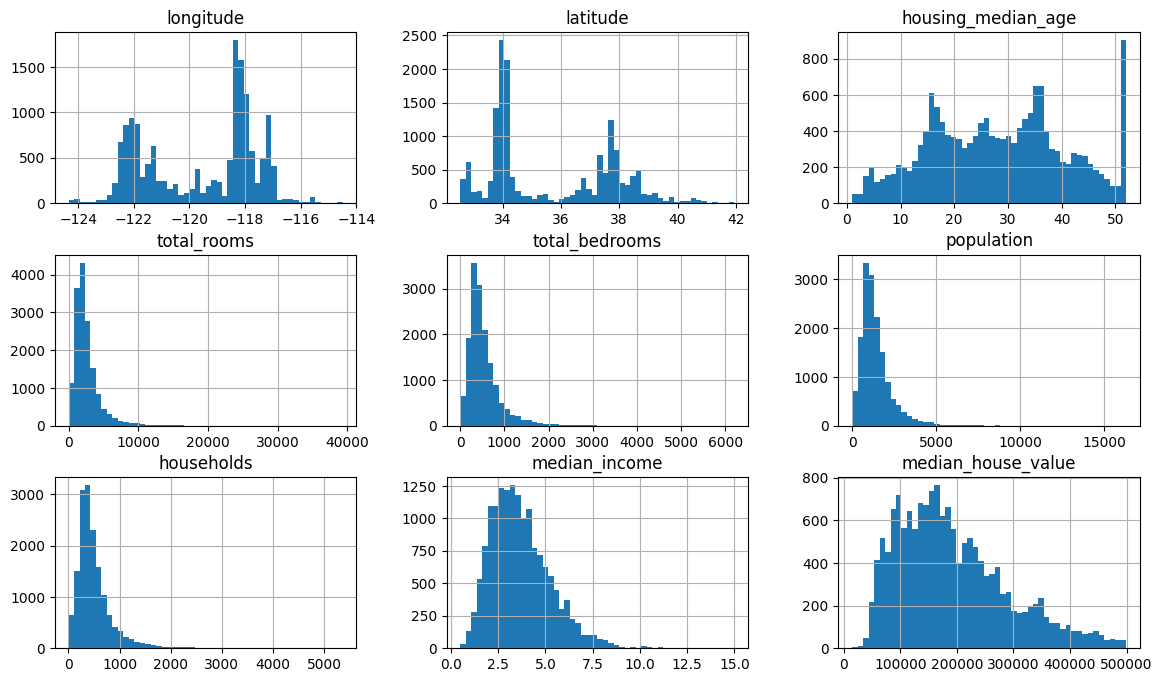

In [26]:
housing_num_tr[housing_num_tr['median_house_value'] < 500000].hist(bins=50, figsize=(14, 8))
plt.show()

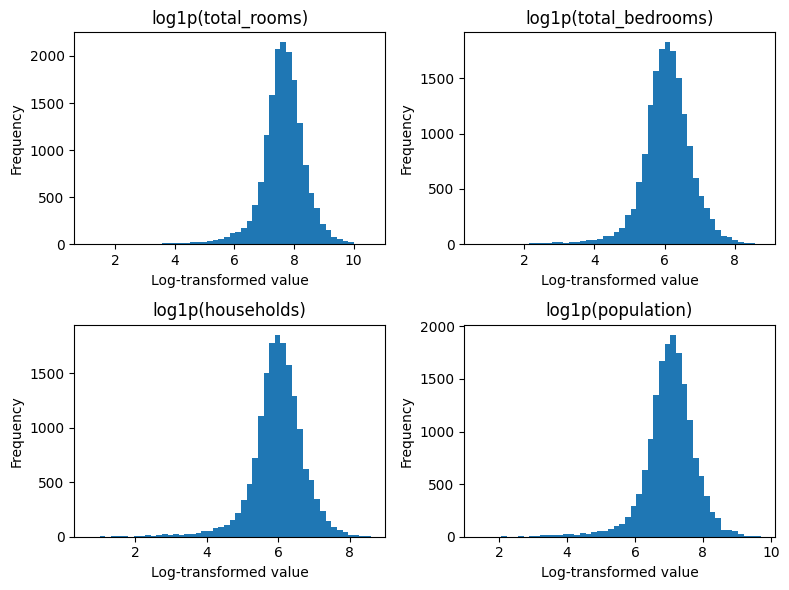

In [27]:
import numpy as np
import matplotlib.pyplot as plt

features = [
    "total_rooms",
    "total_bedrooms",
    "households",
    "population"
]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()

for ax, feature in zip(axes, features):
    log_feature = np.log1p(housing_num_tr[feature])

    ax.hist(log_feature, bins=50)
    ax.set_title(f"log1p({feature})")
    ax.set_xlabel("Log-transformed value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [28]:
housing_num_tr['housing_median_age'].value_counts().head(5)

housing_median_age
52.0    1004
36.0     679
35.0     679
16.0     624
17.0     544
Name: count, dtype: int64

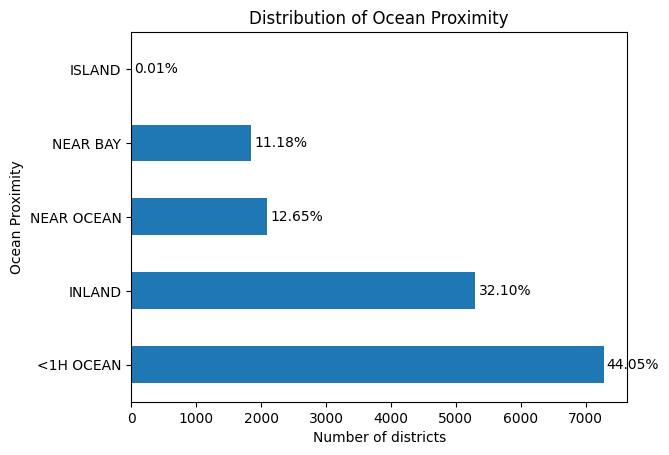

In [29]:
import matplotlib.pyplot as plt

category_counts = housing_cat_tr['ocean_proximity'].value_counts()
category_percentages = category_counts / len(housing_cat_tr) * 100

ax = category_counts.plot(kind='barh')

for i, (count, percentage) in enumerate(zip(category_counts, category_percentages)):
    ax.text(count + 50, i, f'{percentage:.2f}%', va='center')

plt.xlabel("Number of districts")
plt.ylabel("Ocean Proximity")
plt.title("Distribution of Ocean Proximity")
plt.show()

- `total_rooms`, `total_bedrooms`, `households`, and `population` features are right-skewed, So we will apply a log transformation to them.

- `median_house_value` feature (which is the target in this case) is clipped at 500K, which will lead to inefficiency for predictions that are above 500K.

- For `Ocean_Proximity` feature: ISLAND is a near-empty category, which will lead to Unstable weights (linear models), Random splits (trees), and Sparse one-hot columns. So we will merge the ISLAND category into NEAR_OCEAN.

- `housing_median_age` has multiple peaks at 16 and 35 values. We will add a feature for each of the modes representing the similarity between the housing median age and that particular mode. The similarity function that we will use is Gaussian RBF.

- `housing_median_age` is clipped at 52. we will deal with later.



### Bivariate Analsis



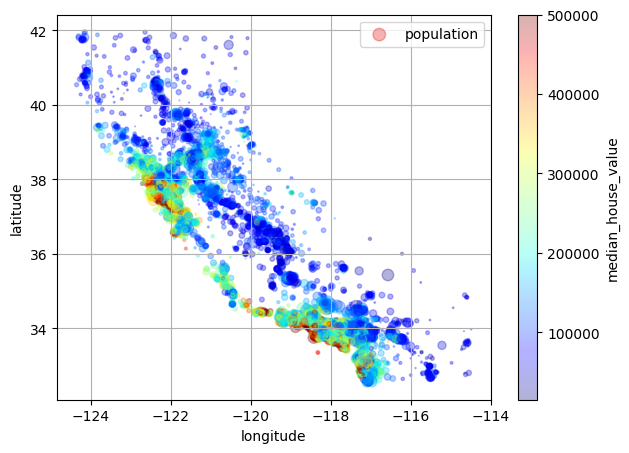

In [30]:
import matplotlib.pyplot as plt

housing_num_tr.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing_num_tr["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(7, 5), alpha=0.3)
plt.show()

A

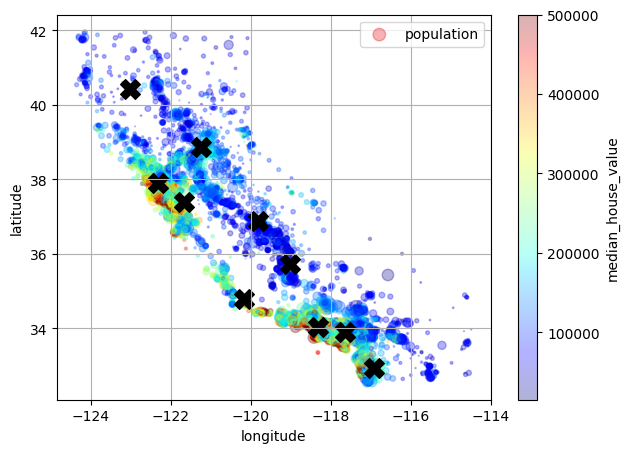

In [31]:
from sklearn.cluster import KMeans

cluster_num = 10

kmeans = KMeans(cluster_num, random_state=123)
kmeans.fit(housing_num_tr[["longitude", "latitude"]])

kmeans.cluster_centers_

housing_num_tr.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing_num_tr["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(7, 5), alpha=0.3)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker="X", s=200, c="black")
plt.show()

Spatial features with strong geographic clustering and non-linear relationships -> Train a K-Means model with n_clusters=10, then apply Gaussian RBF to compute similarity to each cluster

### Target Analysis (Feature-level behavior)

In [32]:
corr_matrix = housing_num_tr.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

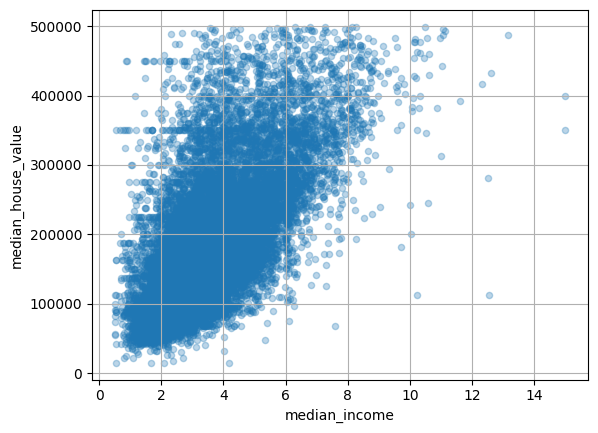

In [33]:
## To-Be-Deleted or test the feature after dropping

import matplotlib.pyplot as plt
import seaborn as sns

housing_num_tr_plot = housing_num_tr[housing_num_tr['median_house_value'] < 500000]

housing_num_tr_plot.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.3, grid=True)
plt.show()


The plot shows a strong but noisy positive correlation, with a clear price cap at 500k. It also reveals several other horizontal price bands (around 450k, 350k, 280k), indicating data artifacts. These quirks could mislead the model, so removing the affected districts may help prevent the algorithm from learning these artificial patterns.

## `Feature Engineering`

In [34]:
housing_num_tr["rooms_per_house"] = housing_num_tr["total_rooms"] / housing_num_tr["households"]
housing_num_tr["bedrooms_ratio"] = housing_num_tr["total_bedrooms"] / housing_num_tr["total_rooms"]
housing_num_tr["people_per_house"] = housing_num_tr["population"] / housing_num_tr["households"]

corr_matrix = housing_num_tr.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

## List of issues found

https://docs.google.com/spreadsheets/d/1Jlc9DdBw2v1I9MhUZ7I47iyZeFC9rpMjYjzpb68LqBE/edit?usp=sharing

## Lets build the preprocessing pipeline

In [35]:
from sklearn.compose import make_column_selector
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np

def merge_island(X):
    X = X.copy()
    X[X == "ISLAND"] = "NEAR OCEAN"
    return X

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
        )


class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)

        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        cluster_centers = self.kmeans_.cluster_centers_
        similarities = rbf_kernel(X, cluster_centers, gamma=self.gamma)
        return similarities

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [36]:
def build_pipeline_func():

    cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    FunctionTransformer(merge_island, feature_names_out="one-to-one"),
    OneHotEncoder(handle_unknown="ignore")
    )

    default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
    )

    geo_pipeline = make_pipeline(
        ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=123)
    )

    log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
    )
    
    preprocessing = ColumnTransformer([
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)), # type: ignore
    ("bedrooms_per_rooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", geo_pipeline, ["latitude", "longitude"])
    ],
        remainder=default_num_pipeline)
    
    return preprocessing


preprocessing = build_pipeline_func()

In [37]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('bedrooms_per_rooms', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``tra

In [38]:
## Before we start with implementing the pipeline let's first drop datapoints with median_house_value > 500K
housing_tr = housing_tr[housing_tr['median_house_value'] < 500000]

X_housing_tr = housing_tr.drop(columns="median_house_value")
y_housing_tr = housing_tr["median_house_value"]

X_prepared_tr = preprocessing.fit_transform(X_housing_tr)
X_prepared_tr.shape

(15725, 23)

In [39]:
housing_prepared_tr = pd.DataFrame(X_prepared_tr, columns=preprocessing.get_feature_names_out(), index=X_housing_tr.index)

In [40]:
housing_prepared_tr.head()

,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,bedrooms_per_rooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,...,geo__Cluster 1 similarity,geo__Cluster 2 similarity,geo__Cluster 3 similarity,geo__Cluster 4 similarity,geo__Cluster 5 similarity,geo__Cluster 6 similarity,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,remainder__housing_median_age
13096,0.0,0.0,1.0,0.0,1.823360,-0.917574,-0.328235,1.332604,0.647615,0.441786,...,1.031938e-14,8.495894e-01,8.854675e-08,3.231739e-24,1.606991e-02,1.883765e-01,5.844314e-18,1.319643e-04,6.668659e-01,1.893045
14973,1.0,0.0,0.0,0.0,-0.538807,0.054902,-0.253248,-0.263852,-0.056525,-0.732839,...,9.509473e-01,8.522456e-12,1.204965e-01,2.668634e-02,2.837794e-16,2.663580e-11,3.678352e-01,3.528276e-04,2.939354e-16,0.933986
3785,0.0,1.0,0.0,0.0,-0.231876,-0.016887,-0.054905,-0.943507,-0.855671,-0.964232,...,3.618583e-15,5.107291e-01,2.447748e-08,9.964006e-25,1.748979e-01,5.216879e-01,4.225814e-18,2.491112e-04,7.161312e-01,0.374536
14689,0.0,1.0,0.0,0.0,-0.178560,-0.009970,-0.143450,0.956387,0.954401,0.656779,...,2.844659e-01,7.977142e-18,4.896669e-04,4.683296e-01,6.227424e-22,1.531124e-16,8.649314e-01,3.293102e-07,4.428320e-23,-0.904208
20507,0.0,0.0,0.0,1.0,0.937159,-0.699757,-0.304682,1.447623,1.014755,0.705446,...,9.444671e-01,1.019857e-13,3.204891e-02,1.075251e-01,1.292669e-18,3.006785e-13,5.285741e-01,2.523709e-05,1.498555e-18,0.614300


## `Model Selection & Training`

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import mlflow
from mlflow import sklearn as mlflow_sklearn
import pandas as pd
import numpy as np


def train_all_models(X, y, preprocessing):

    df_results = {
        "models": [],
        "full_data_train_rmse": [],
        "cv_mean_rmse": [],
        "cv_std_rmse": []
    }

    models = {
        "lin_reg": LinearRegression(),
        "tree_reg": DecisionTreeRegressor(random_state=42),
        "forest_reg": RandomForestRegressor(random_state=42)
    }

    for model_name, model in models.items():

        print(f"{model_name} training...")

        # Nested run only
        with mlflow.start_run(run_name=model_name, nested=True):

            pipeline = make_pipeline(preprocessing, model)
            pipeline.fit(X, y)

            # Train RMSE
            predictions = pipeline.predict(X)
            train_rmse = root_mean_squared_error(y, predictions)

            # Cross-validation
            cv_scores = -cross_val_score(
                pipeline,
                X,
                y,
                scoring="neg_root_mean_squared_error",
                cv=10
            )

            cv_mean = np.mean(cv_scores)
            cv_std = np.std(cv_scores)

            # Log params
            mlflow.log_param("model_type", model_name)
            mlflow.log_params(model.get_params())

            # Log metrics
            mlflow.log_metric("train_rmse", float(train_rmse))
            mlflow.log_metric("cv_mean_rmse", float(cv_mean))
            mlflow.log_metric("cv_std_rmse", float(cv_std))

            # Log model artifact
            mlflow_sklearn.log_model(pipeline, name=model_name)

            # Store results
            df_results["models"].append(model_name)
            df_results["full_data_train_rmse"].append(train_rmse)
            df_results["cv_mean_rmse"].append(cv_mean)
            df_results["cv_std_rmse"].append(cv_std)

    return df_results


df_results = train_all_models(X_housing_tr, y_housing_tr, preprocessing)

lin_reg training...


2026/03/04 22:50:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lin_reg at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0/runs/4b30ac2c7fc643fe8dea7957f3c04a4c
🧪 View experiment at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0
tree_reg training...


2026/03/04 22:50:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run tree_reg at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0/runs/5d852d8963204d6491de4deacc8ba3c9
🧪 View experiment at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0
forest_reg training...


2026/03/04 22:53:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run forest_reg at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0/runs/786d07c3b1da46d78d2d6186bf979bc2
🧪 View experiment at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0


In [42]:
pd.DataFrame(df_results)

,models,full_data_train_rmse,cv_mean_rmse,cv_std_rmse
0,lin_reg,58474.448971,59278.084122,2976.360446
1,tree_reg,0.000000,58964.311518,1574.583164
2,forest_reg,15812.227160,42418.649423,1137.138853


- As this notebook is for practicing perposes, then we will consider the random forst model as the only promising model.

## `Fine-Tune Promising Models`

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import mlflow
import mlflow.sklearn as mlflow_sklearn
import pandas as pd
import numpy as np
from pathlib import Path


def fine_tune_rf(X, y, preprocessing):

    full_pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("random_forest", RandomForestRegressor(random_state=42)),
    ])

    param_grid = [
        {
            'preprocessing__geo__clustersimilarity__n_clusters': [5, 8, 10],
            'random_forest__max_features': [4, 6, 8]
        },
        {
            'preprocessing__geo__clustersimilarity__n_clusters': [10, 15],
            'random_forest__max_features': [6, 8, 10]
        },
    ]

    with mlflow.start_run(run_name="rf_grid_search", nested=True):

        # Log search space (important!)
        mlflow.log_param("cv_folds", 3)
        mlflow.log_param("scoring", "neg_root_mean_squared_error")
        mlflow.log_dict({"param_grid": param_grid}, "param_grid.json") ## TODO: log bugged

        grid_search = GridSearchCV(
            full_pipeline,
            param_grid,
            cv=3,
            scoring='neg_root_mean_squared_error',
            return_train_score=True
        )

        grid_search.fit(X, y)

        # ----------------------------
        # Best Results
        # ----------------------------
        best_params = grid_search.best_params_
        best_score = -grid_search.best_score_

        mlflow.log_params(best_params)
        mlflow.log_metric("best_cv_rmse", best_score)

        # ----------------------------
        # Log full CV results table
        # ----------------------------
        BASE_DIR = Path(os.getcwd()).parent
        results_df = pd.DataFrame(grid_search.cv_results_)
        results_df.to_csv(BASE_DIR / "assets/grid_search_results.csv", index=False)
        mlflow.log_artifact(str(BASE_DIR / "assets/grid_search_results.csv"))

        # ----------------------------
        # Log Best Model
        # ----------------------------
        mlflow_sklearn.log_model(
            grid_search.best_estimator_,
            name="best_random_forest_model"
        )

    return grid_search


grid_search = fine_tune_rf(X_housing_tr, y_housing_tr, preprocessing)

2026/03/04 23:00:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run rf_grid_search at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0/runs/0ea7a7ebfd0d4d328591b5c5c6311a39
🧪 View experiment at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0


In [44]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res.head()  # note: the 1st column is the row ID

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__clustersimilarity__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
12,3.131065,0.043223,0.112671,0.002623,15,6,{'preprocessing__geo__clustersimilarity__n_clu...,-39649.599411,-40603.036202,-40362.903015,-40205.179543,404.901592,1,-15208.448283,-15188.504381,-14879.440069,-15092.130911,150.615372
13,4.013767,0.073598,0.115422,0.001414,15,8,{'preprocessing__geo__clustersimilarity__n_clu...,-40384.309899,-40644.245632,-40859.462795,-40629.339442,194.266509,2,-15356.074235,-15174.753478,-15087.498668,-15206.108793,111.864727
14,4.854869,0.112625,0.110476,0.001747,15,10,{'preprocessing__geo__clustersimilarity__n_clu...,-40366.196259,-41119.152835,-41063.139608,-40849.496234,342.508900,3,-15392.645428,-15296.651811,-15190.778228,-15293.358489,82.444834
6,2.337797,0.098492,0.109712,0.002669,10,4,{'preprocessing__geo__clustersimilarity__n_clu...,-40677.643345,-41376.790513,-41428.390096,-41160.941318,342.391907,4,-15616.789995,-15448.931188,-15313.049128,-15459.590104,124.230533
7,3.081442,0.053977,0.129510,0.019112,10,6,{'preprocessing__geo__clustersimilarity__n_clu...,-40757.545277,-41178.583550,-41654.779878,-41196.969568,366.525139,5,-15595.662464,-15422.950325,-15399.066882,-15472.559890,87.591048


## `Analyzing the Best Models and Their Errors`

In [45]:
final_model = grid_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
sorted(zip(feature_importances, final_model["preprocessing"].get_feature_names_out()), reverse=True)

[(np.float64(0.2129707231977303), 'log__median_income'),
 (np.float64(0.1018520046799805), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.069357629069416), 'geo__Cluster 8 similarity'),
 (np.float64(0.06769254525423817), 'people_per_house__ratio'),
 (np.float64(0.061854691663874195), 'bedrooms_per_rooms__ratio'),
 (np.float64(0.048026158037208146), 'rooms_per_house__ratio'),
 (np.float64(0.043962194728729816), 'geo__Cluster 10 similarity'),
 (np.float64(0.03224699283020727), 'geo__Cluster 2 similarity'),
 (np.float64(0.029977460859121265), 'geo__Cluster 12 similarity'),
 (np.float64(0.029015163869819876), 'geo__Cluster 1 similarity'),
 (np.float64(0.02869911185296142), 'geo__Cluster 5 similarity'),
 (np.float64(0.028526243751591157), 'geo__Cluster 3 similarity'),
 (np.float64(0.02564099500830727), 'geo__Cluster 14 similarity'),
 (np.float64(0.025073159204421065), 'geo__Cluster 4 similarity'),
 (np.float64(0.021675126816061294), 'geo__Cluster 6 similarity'),
 (np.float64(0.0212327520355

- (2nd iteration) We can see from the importance scores that only one `ocean_proximity` category is useful, so we could try dropping the others or merge them all into a new category (i.e. switch ocean_proximity feature into binary one).
- (Future work) Bias analysis.

## `Evaluate Your System on the Test Set`

In [46]:
import mlflow
import mlflow.sklearn as mlflow_sklearn
from mlflow.tracking import MlflowClient
from sklearn.metrics import root_mean_squared_error
from scipy import stats
import numpy as np


def evaluation(
    X_test,
    y_test,
    final_model,
    model_name="HousingModel",
    confidence=0.95
):

    if mlflow.active_run() is None:
        raise RuntimeError("No active MLflow run found.")

    # client = MlflowClient()

    # -------------------------
    # Predictions
    # -------------------------
    final_predictions = final_model.predict(X_test)
    final_rmse = root_mean_squared_error(y_test, final_predictions)

    mlflow.log_metric("test_rmse", final_rmse)
    mlflow.log_param("confidence_level", confidence)
    mlflow.log_param("test_set_size", len(X_test))

    # -------------------------
    # Confidence Interval
    # -------------------------
    def rmse(se):
        return np.sqrt(np.mean(se))

    squared_errors = (final_predictions - y_test) ** 2

    boot_result = stats.bootstrap(
        [squared_errors],
        rmse,
        confidence_level=confidence,
        random_state=42 # type: ignore
    )

    rmse_lower, rmse_upper = boot_result.confidence_interval

    mlflow.log_metric("test_rmse_ci_lower", rmse_lower)
    mlflow.log_metric("test_rmse_ci_upper", rmse_upper)

    # -------------------------
    # Log & Register Model
    # -------------------------
    model_info = mlflow_sklearn.log_model(final_model, name=model_name)

    # model_version = model_info.registered_model_version
    # print(f"Registered Model Version: {model_version}")

    # client = MlflowClient()

    # client.set_registered_model_alias(
    #     name=model_name,
    #     alias="staging",
    #     version=str(model_version)
    # )


    return final_rmse


In [47]:
strat_test_set = strat_test_set[strat_test_set['median_house_value'] < 500000]

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()


rmse = evaluation(X_test, y_test, final_model)


2026/03/04 23:05:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


- Let's assume that we are satisfied with this version for now. So we choose to deploy this model.

In [48]:
import mlflow; mlflow.end_run()

🏃 View run traveling-moth-677 at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0/runs/e32af10c3d264364ada61b4747f32f6d
🧪 View experiment at: https://dagshub.com/abdoashraff185/Testoo.mlflow/#/experiments/0
